<a href="https://colab.research.google.com/github/scxbbard/Machine-Learning_101/blob/main/ML_DTC(titanic).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import seaborn as sns
from sklearn import tree

In [4]:
df = sns.load_dataset("titanic")

In [ ]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


- Feature - whether passenger was in first class
- Target - survived

In [5]:
df[['survived', 'class', 'sex', 'age', 'fare']].head()

,survived,class,sex,age,fare
0,0,Third,male,22.0,7.2500
1,1,First,female,38.0,71.2833
2,1,Third,female,26.0,7.9250
3,1,First,female,35.0,53.1000
4,0,Third,male,35.0,8.0500


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [7]:
df = df[["survived", "class"]].copy()

In [8]:
df['is_first'] = (df['class'] == 'First').astype(int)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   survived  891 non-null    int64   
 1   class     891 non-null    category
 2   is_first  891 non-null    int64   
dtypes: category(1), int64(2)
memory usage: 15.0 KB


In [10]:
df.head()

,survived,class,is_first
0,0,Third,0
1,1,First,1
2,1,Third,0
3,1,First,1
4,0,Third,0


####**Split the data**

In [12]:
X = df[["is_first"]]
y = df[["survived"]]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


####**Model**

In [16]:
model = DecisionTreeClassifier(random_state=42)
model

DecisionTreeClassifier(random_state=42)

####**Fitting**

In [17]:
model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

####**Running prediction**

In [18]:
y_pred = model.predict(X_test)
y_pred

array([0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1,
       1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1,
       1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 0])

####**Plotting decision tree**

[Text(0.5, 0.75, 'x[0] <= 0.5\ngini = 0.469\nsamples = 712\nvalue = [444, 268]'),
 Text(0.25, 0.25, 'gini = 0.426\nsamples = 549\nvalue = [380, 169]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.477\nsamples = 163\nvalue = [64.0, 99.0]'),
 Text(0.625, 0.5, '  False')]

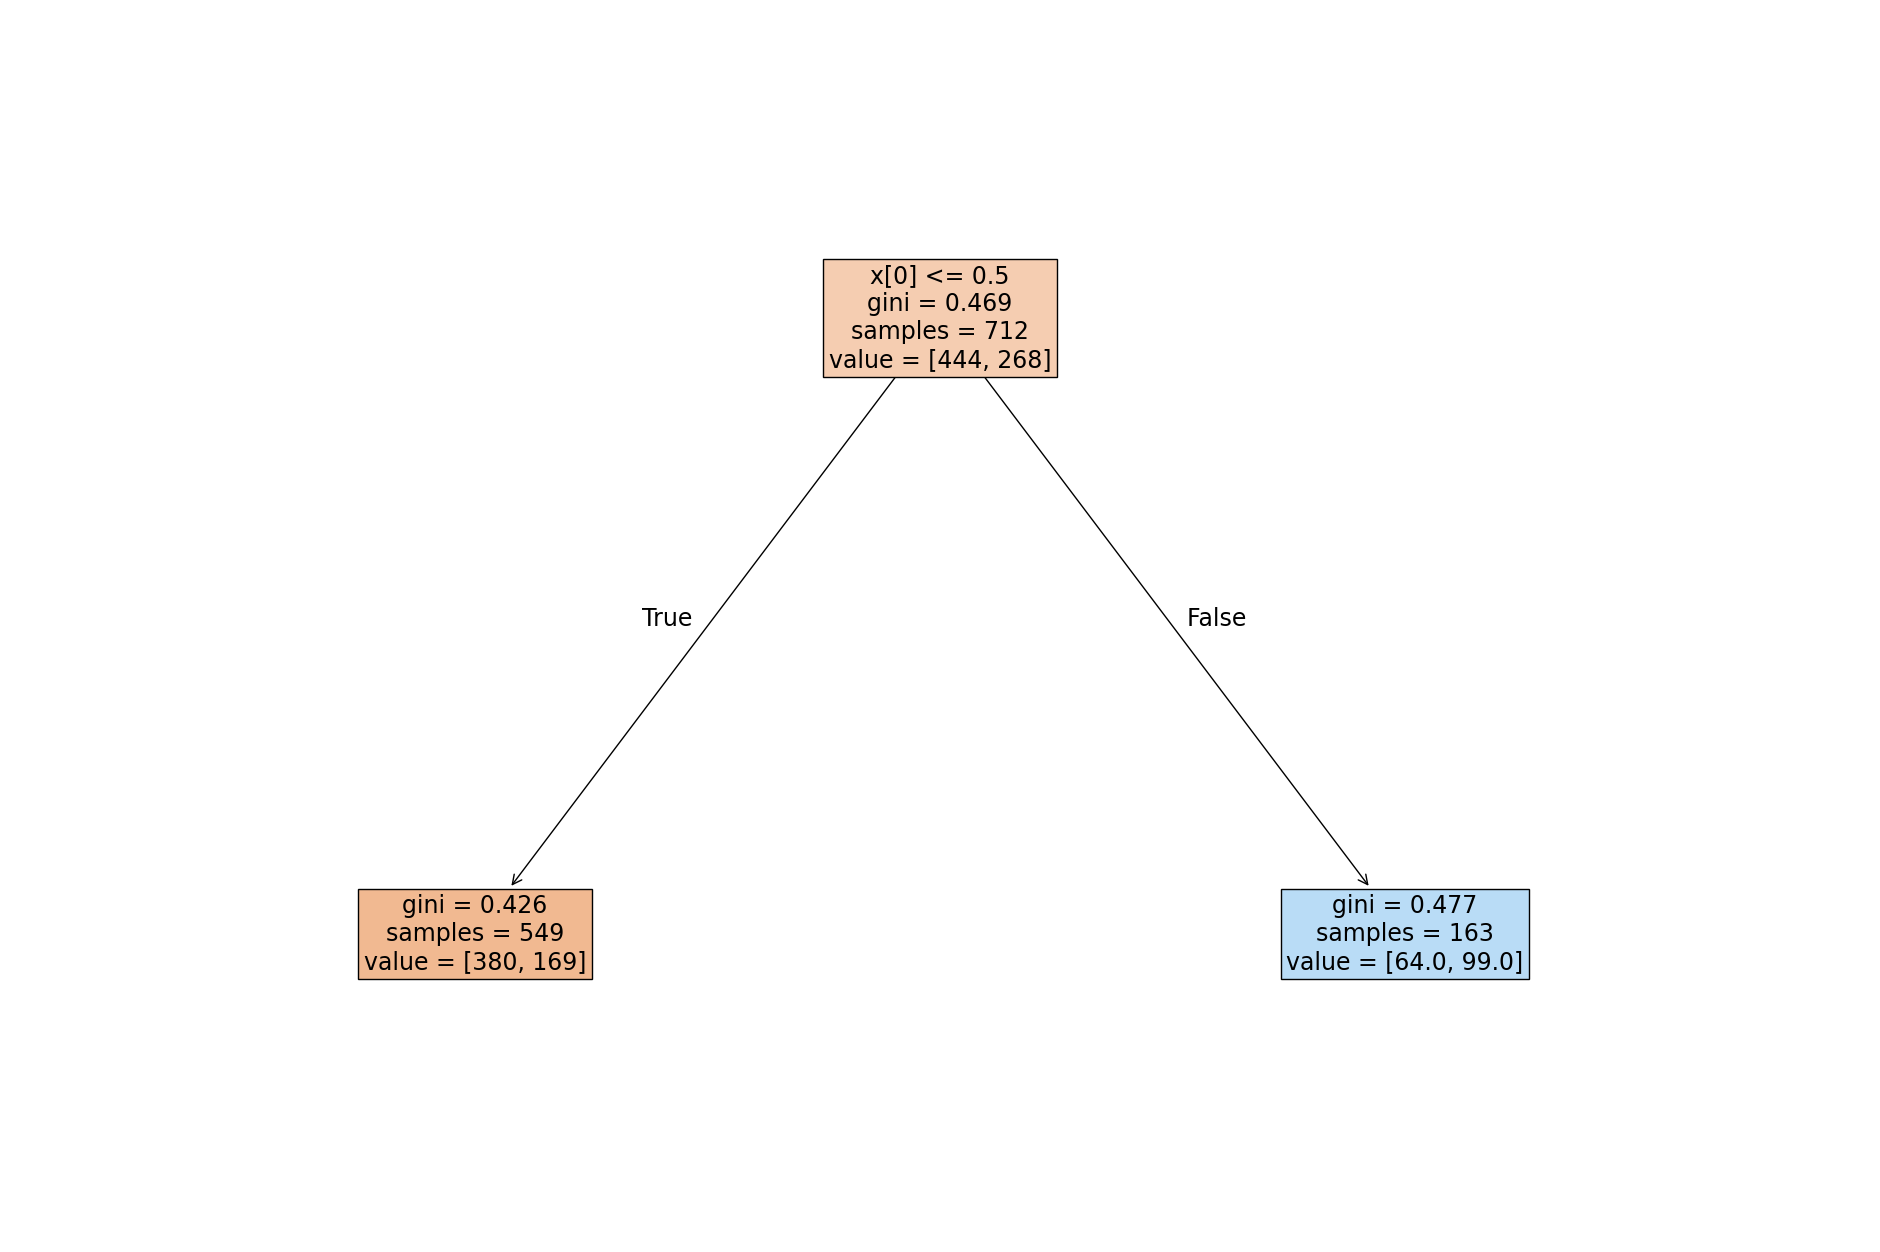

In [24]:
plt.figure(figsize = (24, 16))
tree.plot_tree(model, filled=True, fontsize=17)

In [29]:
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy : {acc * 100:.2f}%")

Accuracy : 70.39%
